# Fase 1 — Adquisición y validación de datos
## Proyecto integrador "La hora dorada"

**Pregunta de investigación:** ¿cuánto tiempo tarda realmente la población de
una región determinada, por carretera, en llegar a un centro de salud con
capacidad resolutiva (categoría II-1 en adelante), y dónde están las peores
brechas?

**Objetivo de esta fase:** construir un conjunto de datos geoespaciales
limpio, validado y documentado de puntos de **demanda** (dónde está la
población: centros poblados de SIGMED/INEI) y puntos de **oferta** (dónde se
brinda atención resolutiva: RENIPRESS/SUSALUD), para 3 departamentos —uno
costero, uno andino y uno amazónico— declarados en `config.md` y
modificables sin tocar el código.

**Fuentes usadas** (provistas en `_data/`, nunca se modifican ahí):
- `RENIPRESS_30-04-2026.csv` — registro nacional de IPRESS (SUSALUD).
- `CP_P.shp` — centros poblados con coordenadas (SIGMED/INEI).
- `DEPARTAMENTO.gpkg` / `PROVINCIA.gpkg` / `DISTRITO.gpkg` — límites
  político-administrativos (INEI, cartografía censal).
- `peru-260907.osm.pbf` — red vial OSM (se usa recién en la Fase 2).

Todos los parámetros (departamentos elegidos, rutas, lista blanca de
categorías, umbrales) viven en `config.md` — este notebook no tiene ningún
valor de ese tipo escrito a mano en una celda de código.

## 0. Configuración

`config.md` es un archivo YAML (con extensión `.md` para que se pueda leer
como documentación). Lo cargamos tal cual, sin copiar sus valores a mano.

In [1]:
from __future__ import annotations

import json
import re
import shutil
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
import geopandas as gpd
import requests
import yaml
from shapely.geometry import Point

pd.set_option("display.max_columns", 50)

REPO_ROOT = Path.cwd()  # este notebook vive en la raíz del repo
CONFIG_PATH = REPO_ROOT / "config.md"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CONFIG = yaml.safe_load(f)


def resolve_path(rel_path: str) -> Path:
    p = Path(rel_path)
    return p if p.is_absolute() else REPO_ROOT / p


def ensure_dirs() -> None:
    for clave in ("raw", "processed", "outputs", "reports"):
        resolve_path(CONFIG["rutas"][clave]).mkdir(parents=True, exist_ok=True)


def departamentos_seleccionados() -> dict[str, str]:
    d = CONFIG["departamentos"]
    return {"costero": d["costero"], "andino": d["andino"], "amazonico": d["amazonico"]}


def codigos_inei_seleccionados() -> dict[str, str]:
    d = CONFIG["departamentos"]
    codigos = d["codigos_inei"]
    nombres = set(departamentos_seleccionados().values())
    faltantes = nombres - set(codigos)
    if faltantes:
        raise ValueError(f"config.md: faltan codigos_inei para {faltantes}")
    return {n: codigos[n] for n in nombres}


ensure_dirs()
print("Departamentos elegidos:", departamentos_seleccionados())
print("Códigos INEI:", codigos_inei_seleccionados())
print("Categorías resolutivas:", CONFIG["categorias"]["resolutivas"])
print("Categorías no concluyentes:", CONFIG["categorias"]["no_concluyentes"])
print("Estado operativo válido:", CONFIG["estado_operativo_valido"])
print("bbox Perú:", CONFIG["validacion"]["bbox_peru"])

Departamentos elegidos: {'costero': 'PIURA', 'andino': 'AYACUCHO', 'amazonico': 'UCAYALI'}
Códigos INEI: {'UCAYALI': '25', 'AYACUCHO': '05', 'PIURA': '20'}
Categorías resolutivas: ['II-1', 'II-2', 'II-E', 'III-1', 'III-2', 'III-E']
Categorías no concluyentes: ['I-1', 'I-2', 'I-3', 'I-4']
Estado operativo válido: ['ACTIVO']
bbox Perú: {'lon_min': -81.4, 'lon_max': -68.6, 'lat_min': -18.4, 'lat_max': -0.04}


## 1. Adquisición de datos

Reglas exigidas por el enunciado y cómo las cumple este bloque:

- **Idempotente**: si el archivo ya existe en `data/raw/`, no se vuelve a
  tocar (parámetro `FORZAR_DESCARGA`, en `False` por defecto).
- **`data/raw/` nunca se modifica a mano**: cada fuente se resuelve por
  alguna de estas 3 vías, en este orden:
  1. Ya existe en `data/raw/` → no se hace nada.
  2. Existe una copia en `_data/` (`cache_local` en `config.md`) → se copia
     a `data/raw/`. `_data/` es justamente la situación que describe el
     enunciado: *"si un portal no está disponible el día que lo ejecute,
     almacene en caché el archivo... y documente la fecha"* — aquí la
     "caché" ya viene provista para el curso.
  3. No hay copia local → se intenta la descarga real (RENIPRESS: se
     busca el CSV mensual más reciente en la página del dataset; OSM:
     descarga directa) o, si la fuente es un portal interactivo sin
     enlace directo (SIGMED, límites administrativos), se imprimen
     instrucciones de descarga manual en vez de fallar en silencio.
- Cada intento queda registrado con fecha en
  `data/raw/download_log.json`.

In [2]:
FORZAR_DESCARGA = False  # cambiar a True para forzar una nueva descarga/copia

ruta_log = resolve_path(CONFIG["rutas"]["log_descargas"])


def _ahora_iso() -> str:
    return datetime.now(timezone.utc).isoformat(timespec="seconds")


def _cargar_log(ruta: Path) -> dict:
    if ruta.exists():
        try:
            return json.loads(ruta.read_text(encoding="utf-8"))
        except json.JSONDecodeError:
            pass
    return {}


def _guardar_log(ruta: Path, log: dict) -> None:
    ruta.parent.mkdir(parents=True, exist_ok=True)
    ruta.write_text(json.dumps(log, indent=2, ensure_ascii=False), encoding="utf-8")


def _registrar(log: dict, clave: str, **campos) -> None:
    entrada = log.setdefault(clave, {})
    entrada["ultima_verificacion"] = _ahora_iso()
    entrada.update(campos)


def _sesion_http() -> requests.Session:
    s = requests.Session()
    # datosabiertos.gob.pe (RENIPRESS) devuelve HTTP 418 a clientes sin
    # user-agent de navegador (bloqueo de su WAF) -- verificado el 2026-09-08.
    s.headers.update({"User-Agent": CONFIG["descargas"]["user_agent"]})
    return s


def _copiar_archivo(origen: Path, destino: Path) -> int:
    destino.parent.mkdir(parents=True, exist_ok=True)
    tmp = destino.with_suffix(destino.suffix + ".part")
    shutil.copyfile(origen, tmp)
    tmp.replace(destino)
    return destino.stat().st_size


def _copiar_shapefile(origen_shp: Path, destino_shp: Path) -> int:
    destino_shp.parent.mkdir(parents=True, exist_ok=True)
    total = 0
    for sidecar in origen_shp.parent.glob(origen_shp.stem + ".*"):
        total += _copiar_archivo(sidecar, destino_shp.parent / (destino_shp.stem + sidecar.suffix))
    return total


def _descargar_a_archivo(sesion: requests.Session, url: str, destino: Path) -> int:
    timeout = CONFIG["descargas"]["timeout_segundos"]
    destino.parent.mkdir(parents=True, exist_ok=True)
    tmp = destino.with_suffix(destino.suffix + ".part")
    total = 0
    with sesion.get(url, stream=True, timeout=timeout) as r:
        r.raise_for_status()
        with open(tmp, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
                    total += len(chunk)
    tmp.replace(destino)
    return total


def _con_reintentos(fn, reintentos: int):
    ultimo_error = None
    for intento in range(1, reintentos + 1):
        try:
            return fn()
        except (requests.RequestException, OSError) as e:
            ultimo_error = e
            print(f"    intento {intento}/{reintentos} falló: {e}")
    raise ultimo_error


def _usar_cache_local(clave: str, cfg: dict, destino: Path, log: dict) -> bool:
    cache_local = cfg.get("cache_local")
    if not cache_local:
        return False
    ruta_cache = resolve_path(cache_local)
    if not ruta_cache.exists():
        return False
    es_shp = ruta_cache.suffix.lower() == ".shp"
    n_bytes = _copiar_shapefile(ruta_cache, destino) if es_shp else _copiar_archivo(ruta_cache, destino)
    fecha_archivo = datetime.fromtimestamp(ruta_cache.stat().st_mtime, tz=timezone.utc).isoformat(timespec="seconds")
    print(f"[{clave}] copiado desde caché local {ruta_cache.name} -> {destino} ({n_bytes / 1e6:.1f} MB)")
    _registrar(log, clave, estado="copiado_desde_cache_local", archivo_local=str(destino),
               cache_local=str(ruta_cache), tamano_bytes=n_bytes, fecha_archivo_cache=fecha_archivo,
               fecha_dato=cfg.get("fecha_cache"), fecha_incorporacion_al_repo=_ahora_iso())
    return True

In [3]:
def descargar_renipress(sesion, log, force):
    clave = "renipress"
    cfg = CONFIG["fuentes"][clave]
    destino = resolve_path(cfg["archivo_local"])
    reintentos = CONFIG["descargas"]["reintentos"]

    if destino.exists() and destino.stat().st_size > 0 and not force:
        print(f"[{clave}] ya existe en {destino}, no se vuelve a obtener.")
        _registrar(log, clave, estado="ya_existia", archivo_local=str(destino), tamano_bytes=destino.stat().st_size)
        return
    if _usar_cache_local(clave, cfg, destino, log):
        return

    print(f"[{clave}] sin caché local; buscando el CSV mensual más reciente en {cfg['url']} ...")
    try:
        def listar():
            r = sesion.get(cfg["url"], timeout=CONFIG["descargas"]["timeout_segundos"])
            r.raise_for_status()
            return r.text

        html = _con_reintentos(listar, reintentos)
        candidatos = sorted(set(re.findall(cfg["patron_archivo"], html)))
        if not candidatos:
            raise RuntimeError("no se encontró ningún enlace que calce con patron_archivo")

        def fecha_de(nombre):
            dd, mm, aaaa = re.search(r"(\d{2})-(\d{2})-(\d{4})", nombre).groups()
            return datetime(int(aaaa), int(mm), int(dd))

        mas_reciente = max(candidatos, key=fecha_de)
        url_archivo = "https://www.datosabiertos.gob.pe/sites/default/files/" + mas_reciente
        print(f"[{clave}] descargando {mas_reciente} ...")
        n_bytes = _con_reintentos(lambda: _descargar_a_archivo(sesion, url_archivo, destino), reintentos)
        print(f"[{clave}] descargado ({n_bytes / 1e6:.1f} MB) -> {destino}")
        _registrar(log, clave, estado="descargado", archivo_local=str(destino), archivo_origen=mas_reciente,
                   url=url_archivo, tamano_bytes=n_bytes, fecha_descarga=_ahora_iso())
    except Exception as e:
        print(f"[{clave}] ERROR: {e}")
        _registrar(log, clave, estado="error", mensaje=str(e), url=cfg["url"])
        if not (destino.exists() and destino.stat().st_size > 0):
            print(f"[{clave}] descarga manual: {cfg['url']} -> guardar en {destino}.")


def descargar_directo(nombre, sesion, log, force):
    cfg = CONFIG["fuentes"][nombre]
    destino = resolve_path(cfg["archivo_local"])
    reintentos = CONFIG["descargas"]["reintentos"]

    if destino.exists() and destino.stat().st_size > 0 and not force:
        print(f"[{nombre}] ya existe en {destino}, no se vuelve a obtener.")
        _registrar(log, nombre, estado="ya_existia", archivo_local=str(destino), tamano_bytes=destino.stat().st_size)
        return
    if _usar_cache_local(nombre, cfg, destino, log):
        return

    print(f"[{nombre}] sin caché local; descargando {cfg['url']} ...")
    try:
        n_bytes = _con_reintentos(lambda: _descargar_a_archivo(sesion, cfg["url"], destino), reintentos)
        print(f"[{nombre}] descargado ({n_bytes / 1e6:.1f} MB) -> {destino}")
        _registrar(log, nombre, estado="descargado", archivo_local=str(destino), url=cfg["url"],
                   tamano_bytes=n_bytes, fecha_descarga=_ahora_iso())
    except Exception as e:
        print(f"[{nombre}] ERROR: {e}")
        _registrar(log, nombre, estado="error", mensaje=str(e), url=cfg["url"])
        if not (destino.exists() and destino.stat().st_size > 0):
            print(f"[{nombre}] descarga manual: {cfg['url']} -> guardar en {destino}.")


def verificar_manual(nombre, cfg, log, force=False):
    destino = resolve_path(cfg["archivo_local"])
    if destino.exists() and destino.stat().st_size > 0 and not force:
        print(f"[{nombre}] ya existe en {destino}, no se vuelve a obtener.")
        _registrar(log, nombre, estado="ya_existia", archivo_local=str(destino), tamano_bytes=destino.stat().st_size)
        return
    if _usar_cache_local(nombre, cfg, destino, log):
        return
    origen = cfg.get("url") or cfg.get("fuente")
    print(f"[{nombre}] requiere descarga manual: {origen}\n    Guarda el archivo en: {destino}")
    _registrar(log, nombre, estado="manual_requerido", archivo_local=str(destino), url_origen=origen)


def procesar_fuente(nombre, sesion, log, force):
    cfg = CONFIG["fuentes"][nombre]
    if nombre == "limites_administrativos":
        for capa, cfg_capa in cfg["capas"].items():
            clave = f"limites_administrativos.{capa}"
            cfg_capa = {**cfg_capa, "url": cfg.get("fuente"), "fuente": cfg.get("fuente")}
            verificar_manual(clave, cfg_capa, log, force)
        return
    tipo = cfg["tipo_descarga"]
    if nombre == "renipress":
        descargar_renipress(sesion, log, force)
    elif tipo == "directo":
        descargar_directo(nombre, sesion, log, force)
    elif tipo == "manual":
        verificar_manual(nombre, cfg, log, force)
    else:
        raise ValueError(f"tipo_descarga desconocido para {nombre}: {tipo}")

In [4]:
log_descargas = _cargar_log(ruta_log)
sesion = _sesion_http()

for nombre in ("renipress", "sigmed", "osm_peru", "limites_administrativos"):
    procesar_fuente(nombre, sesion, log_descargas, FORZAR_DESCARGA)
    _guardar_log(ruta_log, log_descargas)

print(f"\nRegistro de descargas -> {ruta_log}")
pd.DataFrame(log_descargas).T

[renipress] copiado desde caché local RENIPRESS_30-04-2026.csv -> C:\Users\User\Documents\GitHub\proyecto-acceso-salud\data\raw\renipress.csv (19.1 MB)

[sigmed] copiado desde caché local CP_P.shp -> C:\Users\User\Documents\GitHub\proyecto-acceso-salud\data\raw\centros_poblados.shp (84.0 MB)


[osm_peru] copiado desde caché local peru-260907.osm.pbf -> C:\Users\User\Documents\GitHub\proyecto-acceso-salud\data\raw\peru-latest.osm.pbf (255.9 MB)
[limites_administrativos.departamento] copiado desde caché local DEPARTAMENTO.gpkg -> C:\Users\User\Documents\GitHub\proyecto-acceso-salud\data\raw\limites_departamento.gpkg (5.5 MB)
[limites_administrativos.provincia] copiado desde caché local PROVINCIA.gpkg -> C:\Users\User\Documents\GitHub\proyecto-acceso-salud\data\raw\limites_provincia.gpkg (12.1 MB)


[limites_administrativos.distrito] copiado desde caché local DISTRITO.gpkg -> C:\Users\User\Documents\GitHub\proyecto-acceso-salud\data\raw\limites_distrito.gpkg (29.1 MB)

Registro de descargas -> C:\Users\User\Documents\GitHub\proyecto-acceso-salud\data\raw\download_log.json


,ultima_verificacion,estado,archivo_local,cache_local,tamano_bytes,fecha_archivo_cache,fecha_dato,fecha_incorporacion_al_repo
renipress,2026-09-08T15:50:48+00:00,copiado_desde_cache_local,C:\Users\User\Documents\GitHub\proyecto-acceso...,C:\Users\User\Documents\GitHub\proyecto-acceso...,19074859,2026-09-08T13:29:29+00:00,2026-04-30,2026-09-08T15:50:48+00:00
sigmed,2026-09-08T15:50:49+00:00,copiado_desde_cache_local,C:\Users\User\Documents\GitHub\proyecto-acceso...,C:\Users\User\Documents\GitHub\proyecto-acceso...,83993256,2020-02-05T17:49:00+00:00,None,2026-09-08T15:50:49+00:00
osm_peru,2026-09-08T15:50:51+00:00,copiado_desde_cache_local,C:\Users\User\Documents\GitHub\proyecto-acceso...,C:\Users\User\Documents\GitHub\proyecto-acceso...,255851767,2026-09-08T13:29:29+00:00,2026-09-07,2026-09-08T15:50:51+00:00
limites_administrativos.departamento,2026-09-08T15:50:51+00:00,copiado_desde_cache_local,C:\Users\User\Documents\GitHub\proyecto-acceso...,C:\Users\User\Documents\GitHub\proyecto-acceso...,5492736,2026-03-06T16:55:14+00:00,None,2026-09-08T15:50:51+00:00
limites_administrativos.provincia,2026-09-08T15:50:51+00:00,copiado_desde_cache_local,C:\Users\User\Documents\GitHub\proyecto-acceso...,C:\Users\User\Documents\GitHub\proyecto-acceso...,12111872,2026-03-06T16:55:24+00:00,None,2026-09-08T15:50:51+00:00
limites_administrativos.distrito,2026-09-08T15:50:51+00:00,copiado_desde_cache_local,C:\Users\User\Documents\GitHub\proyecto-acceso...,C:\Users\User\Documents\GitHub\proyecto-acceso...,29106176,2026-03-06T16:55:36+00:00,None,2026-09-08T15:50:51+00:00


## 2. Informe de calidad de datos: acumulador

Cada regla de validación llama a `reporte.registrar(...)`. Nada se descarta
en silencio: incluso cuando la acción es *"no evaluado"* (por ejemplo, si
faltara la capa de límites administrativos) queda una fila en el informe
explicando por qué.

In [5]:
class ReporteCalidad:
    def __init__(self, dataset: str):
        self.dataset = dataset
        self.reglas: list[dict] = []

    def registrar(self, regla, n_marcados, accion, motivo, n_total=None):
        pct = round(100 * n_marcados / n_total, 2) if n_total else None
        self.reglas.append({"regla": regla, "registros_marcados": int(n_marcados), "porcentaje": pct,
                             "accion": accion, "motivo": motivo})
        pct_txt = f" ({pct}%)" if pct is not None else ""
        print(f"  [{self.dataset}] {regla}: {n_marcados}{pct_txt} -> {accion}")

    def como_dict(self):
        return {"dataset": self.dataset, "generado": datetime.now(timezone.utc).isoformat(timespec="seconds"),
                "reglas": self.reglas}

    def como_tabla(self) -> pd.DataFrame:
        return pd.DataFrame(self.reglas)


reporte = ReporteCalidad("renipress_y_centros_poblados")

## 3. RENIPRESS (oferta) — esquema y normalización

Columnas reales del CSV publicado por SUSALUD (verificadas directamente
sobre el archivo, no supuestas): `INSTITUCION;COD_IPRESS;NOMBRE;
CLASIFICACION;TIPO_ESTABLECIMIENTO;DEPARTAMENTO;PROVINCIA;DISTRITO;UBIGEO;
DIRECCION;...;CATEGORIA;...;ESTADO;NORTE;ESTE;...`

**Quirk importante, documentado aquí porque RENIPRESS no lo documenta**:
`NORTE`/`ESTE` son nombres heredados de un esquema UTM, pero en la práctica
contienen **latitud/longitud en grados decimales** (`NORTE`=latitud,
`ESTE`=longitud), no coordenadas UTM en metros.

In [6]:
RENIPRESS_COLUMNAS = {
    "id": "COD_IPRESS", "nombre": "NOMBRE", "categoria_raw": "CATEGORIA", "estado_raw": "ESTADO",
    "departamento": "DEPARTAMENTO", "provincia": "PROVINCIA", "distrito": "DISTRITO", "ubigeo": "UBIGEO",
    "lat": "NORTE", "lon": "ESTE",
}
COLUMNAS_TEXTO_RENIPRESS = ["NOMBRE", "DIRECCION", "INSTITUCION", "UNIDAD_EJECUTORA",
                            "DEPARTAMENTO", "PROVINCIA", "DISTRITO"]

# --- Regla: codificación de texto (UTF-8 vs Latin-1) ---
# Mojibake conocido: verificado en RENIPRESS, donde 'ñ' se exporta corrupta
# como 'ÿ' (y 'Ñ' como 'Ÿ'), un bug de transcodificación aguas arriba
# (probable Windows-1252 -> UTF-8 mal aplicado sobre los bytes 0xF1/0xD1).
_MOJIBAKE_DIRECTO = {"ÿ": "ñ", "Ÿ": "Ñ"}
# Señal de doble codificación (UTF-8 leído como Latin-1, p. ej. 'Ã±' en vez
# de 'ñ'): si aparece, se intenta revertir con encode('latin-1').decode('utf-8').
_MARCAS_DOBLE_CODIFICACION = ("Ã", "Â", "�")


def corregir_mojibake(valor):
    if not isinstance(valor, str) or not valor:
        return valor, False
    corregido, cambiado = valor, False
    for malo, bueno in _MOJIBAKE_DIRECTO.items():
        if malo in corregido:
            corregido = corregido.replace(malo, bueno)
            cambiado = True
    if any(marca in corregido for marca in _MARCAS_DOBLE_CODIFICACION):
        try:
            corregido = corregido.encode("latin-1").decode("utf-8")
            cambiado = True
        except (UnicodeDecodeError, UnicodeEncodeError):
            pass
    return corregido, cambiado


def corregir_codificacion_columnas(df, columnas, reporte):
    total = 0
    for col in columnas:
        if col not in df.columns:
            continue
        resultados = df[col].map(corregir_mojibake)
        df[col] = resultados.map(lambda r: r[0])
        total += sum(1 for r in resultados if r[1])
    reporte.registrar("codificacion_texto_utf8_vs_latin1", total, "corregido" if total else "sin problemas detectados",
                       "reemplazo de mojibake conocido (ÿ->ñ, Ÿ->Ñ) y reversión de doble codificación UTF-8/Latin-1")
    return df

In [7]:
# --- Regla: normalización de CATEGORIA (no está limpia en el CSV crudo) ---
# 1. Se ignoran mayúsculas/minúsculas y espacios.
# 2. Vacío, nulo o "0" -> categoría desconocida (RENIPRESS usa "0" como
#    centinela de "sin categorizar").
# 3. Cadena que calza con romano (I..III) + sufijo (1,2,3,E), con o sin
#    guion, se reescribe a la forma canónica "II-1".
# 4. Cualquier otra cadena -> categoría desconocida (se conserva el dato
#    crudo, pero no participa del cálculo de oferta resolutiva).
_PATRON_CATEGORIA = re.compile(r"^(I{1,3})-?(1|2|3|E)$")
_CATEGORIA_VACIA = {"", "0", "NAN", "NONE", "S/C", "SINCATEGORIA", "SINCATEGORÍA"}


def normalizar_categoria(raw):
    if raw is None:
        return None
    txt = re.sub(r"\s+", "", str(raw).strip().upper())
    if txt in _CATEGORIA_VACIA:
        return None
    m = _PATRON_CATEGORIA.match(txt)
    return f"{m.group(1)}-{m.group(2)}" if m else None


def clasificar_categoria(categoria_normalizada):
    resolutivas = set(CONFIG["categorias"]["resolutivas"])
    no_concluyentes = set(CONFIG["categorias"]["no_concluyentes"])
    if categoria_normalizada in resolutivas:
        return "resolutiva"
    if categoria_normalizada in no_concluyentes:
        return "no_concluyente"
    return "desconocida"


def normalizar_estado(raw):
    return str(raw).strip().upper()


def es_estado_activo(estado_normalizado):
    return estado_normalizado in {v.upper() for v in CONFIG["estado_operativo_valido"]}

In [8]:
# --- Regla: coordenadas (faltantes, cero, intercambiadas, fuera de Perú) ---
def limpiar_coordenadas(df, lat_col, lon_col, reporte):
    bbox = CONFIG["validacion"]["bbox_peru"]
    tol = CONFIG["validacion"]["tolerancia_coordenada_cero"]
    n_total = len(df)

    lat = pd.to_numeric(df[lat_col], errors="coerce")
    lon = pd.to_numeric(df[lon_col], errors="coerce")

    faltante = lat.isna() | lon.isna()
    reporte.registrar("coordenadas_faltantes_o_nulas", int(faltante.sum()), "eliminado",
                       "sin coordenada numérica no se puede calcular la distancia por carretera (Fase 2)", n_total)
    df, lat, lon = df.loc[~faltante].copy(), lat.loc[~faltante], lon.loc[~faltante]

    cero = lat.abs().lt(tol) | lon.abs().lt(tol)
    reporte.registrar("coordenadas_cero", int(cero.sum()), "eliminado",
                       f"|valor| < {tol} se trata como centinela de nulo, no coordenada real", n_total)
    df, lat, lon = df.loc[~cero].copy(), lat.loc[~cero], lon.loc[~cero]

    dentro_actual = lat.between(bbox["lat_min"], bbox["lat_max"]) & lon.between(bbox["lon_min"], bbox["lon_max"])
    dentro_si_swap = lon.between(bbox["lat_min"], bbox["lat_max"]) & lat.between(bbox["lon_min"], bbox["lon_max"])
    intercambiada = (~dentro_actual) & dentro_si_swap
    reporte.registrar("coordenadas_lat_lon_intercambiadas", int(intercambiada.sum()), "corregido",
                       "el par (lat,lon) cae fuera de Perú pero (lon,lat) cae dentro: se intercambian los valores",
                       n_total)
    lat_final = lat.mask(intercambiada, lon)
    lon_final = lon.mask(intercambiada, lat)
    df[lat_col] = lat_final
    df[lon_col] = lon_final

    fuera_bbox = ~(lat_final.between(bbox["lat_min"], bbox["lat_max"])
                   & lon_final.between(bbox["lon_min"], bbox["lon_max"]))
    reporte.registrar("coordenadas_fuera_de_peru", int(fuera_bbox.sum()), "eliminado",
                       f"fuera de lon[{bbox['lon_min']},{bbox['lon_max']}] x lat[{bbox['lat_min']},{bbox['lat_max']}] "
                       "y no se explica por un intercambio lat/lon", n_total)
    return df.loc[~fuera_bbox].copy()


def eliminar_duplicados(df, id_col, reporte):
    n_total = len(df)
    dup = df[id_col].duplicated(keep="first")
    reporte.registrar("codigos_duplicados", int(dup.sum()), "eliminado (se conserva la primera aparición)",
                       f"'{id_col}' debe identificar un único establecimiento/centro poblado", n_total)
    return df.loc[~dup].copy()


def _detectar_columna(columnas, candidatos):
    normalizadas = {re.sub(r"[^A-Z0-9]", "", str(c).upper()): c for c in columnas}
    for cand in candidatos:
        clave = re.sub(r"[^A-Z0-9]", "", cand.upper())
        if clave in normalizadas:
            return normalizadas[clave]
    return None

In [9]:
def _leer_csv_detectando_encoding(ruta, sep, encoding_esperado, reporte):
    try:
        df = pd.read_csv(ruta, sep=sep, encoding=encoding_esperado, dtype=str, low_memory=False)
        reporte.registrar("codificacion_archivo", 0, f"leído como {encoding_esperado}",
                           "el archivo decodifica correctamente con el encoding declarado en config.md")
        return df
    except UnicodeDecodeError:
        import chardet
        deteccion = chardet.detect(ruta.read_bytes()[:200_000])
        encoding_detectado = deteccion["encoding"] or "latin-1"
        reporte.registrar("codificacion_archivo", 1, f"leído como {encoding_detectado} (detectado por chardet)",
                           f"{ruta.name} no decodifica como {encoding_esperado} "
                           f"(confianza chardet: {deteccion['confidence']:.2f})")
        return pd.read_csv(ruta, sep=sep, encoding=encoding_detectado, dtype=str, low_memory=False)


def cargar_renipress(reporte):
    cfg = CONFIG["fuentes"]["renipress"]
    ruta = resolve_path(cfg["archivo_local"])
    if not ruta.exists():
        raise FileNotFoundError(f"No se encontró {ruta}. Corre primero la celda de adquisición.")

    df = _leer_csv_detectando_encoding(ruta, cfg["separador"], cfg["encoding"], reporte)
    n_original = len(df)

    df = corregir_codificacion_columnas(df, COLUMNAS_TEXTO_RENIPRESS, reporte)

    id_col = RENIPRESS_COLUMNAS["id"]
    df = limpiar_coordenadas(df, RENIPRESS_COLUMNAS["lat"], RENIPRESS_COLUMNAS["lon"], reporte)
    df = eliminar_duplicados(df, id_col, reporte)

    df["categoria_normalizada"] = df[RENIPRESS_COLUMNAS["categoria_raw"]].map(normalizar_categoria)
    df["categoria_grupo"] = df["categoria_normalizada"].map(clasificar_categoria)
    reporte.registrar("categoria_no_reconocida", int((df["categoria_grupo"] == "desconocida").sum()),
                       "conservado con advertencia (excluido del cálculo de más cercano)",
                       "CATEGORIA vacía, '0' o que no calza con el patrón romano-sufijo", len(df))

    df["estado_normalizado"] = df[RENIPRESS_COLUMNAS["estado_raw"]].map(normalizar_estado)
    df["operativo_activo"] = df["estado_normalizado"].map(es_estado_activo)
    # Resolutivo si y solo si está activo Y su categoría está en la lista blanca de config.md.
    df["resolutiva"] = df["operativo_activo"] & (df["categoria_grupo"] == "resolutiva")

    lon = pd.to_numeric(df[RENIPRESS_COLUMNAS["lon"]])
    lat = pd.to_numeric(df[RENIPRESS_COLUMNAS["lat"]])
    gdf = gpd.GeoDataFrame(df, geometry=[Point(xy) for xy in zip(lon, lat)], crs="EPSG:4326")

    n_final = len(gdf)
    reporte.registrar("resumen_renipress", n_original - n_final, "eliminado (acumulado de las reglas anteriores)",
                       f"{n_final} de {n_original} registros conservados ({100 * n_final / n_original:.1f}%)",
                       n_original)
    return gdf


salud = cargar_renipress(reporte)
salud[["NOMBRE", "DEPARTAMENTO", "DISTRITO", "CATEGORIA", "categoria_normalizada", "categoria_grupo",
       "ESTADO", "resolutiva"]].head(8)

  [renipress_y_centros_poblados] codificacion_archivo: 0 -> leído como utf-8-sig


  [renipress_y_centros_poblados] codificacion_texto_utf8_vs_latin1: 4 -> corregido
  [renipress_y_centros_poblados] coordenadas_faltantes_o_nulas: 13147 (37.06%) -> eliminado
  [renipress_y_centros_poblados] coordenadas_cero: 7 (0.02%) -> eliminado
  [renipress_y_centros_poblados] coordenadas_lat_lon_intercambiadas: 0 (0.0%) -> corregido
  [renipress_y_centros_poblados] coordenadas_fuera_de_peru: 0 (0.0%) -> eliminado
  [renipress_y_centros_poblados] codigos_duplicados: 0 (0.0%) -> eliminado (se conserva la primera aparición)


  [renipress_y_centros_poblados] categoria_no_reconocida: 2988 (13.39%) -> conservado con advertencia (excluido del cálculo de más cercano)


  [renipress_y_centros_poblados] resumen_renipress: 13154 (37.08%) -> eliminado (acumulado de las reglas anteriores)


,NOMBRE,DEPARTAMENTO,DISTRITO,CATEGORIA,categoria_normalizada,categoria_grupo,ESTADO,resolutiva
0,LA NOVIA,MADRE DE DIOS,TAHUAMANU,I-1,I-1,no_concluyente,ACTIVO,False
1,SANTA MARIA,MADRE DE DIOS,TAHUAMANU,I-1,I-1,no_concluyente,ACTIVO,False
2,P.S. CAMBRUNE,MOQUEGUA,CARUMAS,I-2,I-2,no_concluyente,ACTIVO,False
3,CENTRO DE SALUD CARUMAS,MOQUEGUA,CARUMAS,I-3,I-3,no_concluyente,ACTIVO,False
4,P.S. SACUAYA,MOQUEGUA,CUCHUMBAYA,I-2,I-2,no_concluyente,ACTIVO,False
5,SOCORRO,HUANCAVELICA,PAMPAS,I-2,I-2,no_concluyente,ACTIVO,False
6,DOS DE MAYO,HUANCAVELICA,ACRAQUIA,I-2,I-2,no_concluyente,ACTIVO,False
7,AHUAYCHA,HUANCAVELICA,AHUAYCHA,I-2,I-2,no_concluyente,ACTIVO,False


## 4. Límites administrativos y chequeo de punto-en-su-polígono

*"Los puntos que quedan fuera del polígono del distrito quedan registrados
por ellos mismos"*: no se eliminan (el polígono puede ser el impreciso, no
el punto), quedan marcados con su propio registro en un CSV de detalle.

In [10]:
def marcar_fuera_de_poligono(gdf_puntos, gdf_distritos, ubigeo_col_puntos, ubigeo_col_poligonos,
                             reporte, ruta_detalle):
    gdf_puntos = gdf_puntos.reset_index(drop=True)
    distritos = gdf_distritos[[ubigeo_col_poligonos, "geometry"]].rename(
        columns={ubigeo_col_poligonos: "_ubigeo_poligono"})
    unido = gpd.sjoin(gdf_puntos, distritos, how="left", predicate="within")
    unido = unido[~unido.index.duplicated(keep="first")].reindex(gdf_puntos.index)

    ubigeo_punto = gdf_puntos[ubigeo_col_puntos].astype(str)
    ubigeo_poligono = unido["_ubigeo_poligono"].astype(str)
    fuera = unido["_ubigeo_poligono"].isna() | (ubigeo_poligono != ubigeo_punto)

    gdf_puntos = gdf_puntos.copy()
    gdf_puntos["fuera_de_poligono_distrital"] = fuera.to_numpy()
    reporte.registrar("puntos_fuera_de_su_poligono_distrital", int(fuera.sum()), "conservado con advertencia",
                       "el punto no cae dentro del polígono del distrito que declara su propio UBIGEO",
                       len(gdf_puntos))
    if fuera.any():
        cols = [c for c in [ubigeo_col_puntos, "NOMBRE", "DEPARTAMENTO", "DISTRITO"] if c in gdf_puntos.columns]
        gdf_puntos.loc[fuera, cols].to_csv(ruta_detalle, index=False, encoding="utf-8-sig")
        print(f"    detalle -> {ruta_detalle}")
    return gdf_puntos


def cargar_limites_administrativos():
    capas = CONFIG["fuentes"]["limites_administrativos"]["capas"]
    ruta = resolve_path(capas["distrito"]["archivo_local"])
    if not ruta.exists():
        return None
    gdf = gpd.read_file(ruta)
    return gdf.set_crs("EPSG:4326") if gdf.crs is None else gdf.to_crs("EPSG:4326")


ruta_reportes = resolve_path(CONFIG["rutas"]["reports"])
ruta_reportes.mkdir(parents=True, exist_ok=True)

distritos = cargar_limites_administrativos()
ubigeo_col_poligonos = _detectar_columna(distritos.columns, ["UBIGEO", "IDDIST", "UBIGEO_DIST", "COD_DIST"]) \
    if distritos is not None else None

if distritos is not None and ubigeo_col_poligonos:
    salud = marcar_fuera_de_poligono(salud, distritos, RENIPRESS_COLUMNAS["ubigeo"], ubigeo_col_poligonos,
                                      reporte, ruta_reportes / "renipress_fuera_de_poligono.csv")
else:
    reporte.registrar("puntos_fuera_de_su_poligono_distrital", 0, "no evaluado",
                       "no hay límites administrativos en caché o no se identificó su columna UBIGEO", len(salud))

salud[salud.get("fuera_de_poligono_distrital", False) == True][
    ["NOMBRE", "DEPARTAMENTO", "DISTRITO"]].head(10)

  [renipress_y_centros_poblados] puntos_fuera_de_su_poligono_distrital: 1683 (7.54%) -> conservado con advertencia
    detalle -> C:\Users\User\Documents\GitHub\proyecto-acceso-salud\logs\renipress_fuera_de_poligono.csv


,NOMBRE,DEPARTAMENTO,DISTRITO
32,FONAVI IV,ICA,SUBTANJALLA
47,P.S. CHACLAYA,MOQUEGUA,UBINAS
52,CONSULTORIOS MEDICOS LIDER MEDIC EIRL,LIMA,SAN MARTIN DE PORRES
56,PUESTO DE SALUD CCARHUACCPAMPA,AYACUCHO,PARAS
65,P.S. QUINSACHATA,MOQUEGUA,UBINAS
70,PUESTO DE SALUD CONCHACHIRI,TACNA,TARATA
78,CCASAPATA,HUANCAVELICA,YAULI
87,COLLACACHI,PUNO,PICHACANI
99,LAQUI,PUNO,ACORA
108,TU SONRISA CONSULTORIO DENTAL,LIMA,LOS OLIVOS


## 5. Centros poblados (demanda)

`CP_P.shp` ya trae geometría de punto (no hay que construirla desde
columnas lat/lon como en RENIPRESS). Las reglas que sí aplican: geometría
faltante/vacía, fuera del bbox de Perú, códigos duplicados (`CODCP`),
codificación de texto, y el mismo chequeo de punto-en-su-distrito.

In [11]:
def cargar_centros_poblados(reporte):
    cfg = CONFIG["fuentes"]["sigmed"]
    ruta = resolve_path(cfg["archivo_local"])
    if not ruta.exists():
        print(f"  [centros_poblados] no se encontró {ruta}.")
        reporte.registrar("archivo_no_disponible", 0, "omitido",
                           f"no existe {ruta}; SIGMED requiere descarga manual desde {cfg['url']}", 0)
        return None

    gdf = gpd.read_file(ruta)
    n_original = len(gdf)
    gdf = gdf.set_crs("EPSG:4326") if gdf.crs is None else gdf.to_crs("EPSG:4326")

    invalida = gdf.geometry.isna() | gdf.geometry.is_empty
    reporte.registrar("geometria_faltante_o_vacia", int(invalida.sum()), "eliminado",
                       "sin geometría no se puede calcular distancia por carretera", n_original)
    gdf = gdf.loc[~invalida].copy()

    columnas_texto = [c for c in gdf.columns if gdf[c].dtype == object and c != "geometry"]
    gdf = corregir_codificacion_columnas(gdf, columnas_texto, reporte)

    bbox = CONFIG["validacion"]["bbox_peru"]
    punto = gdf.geometry.representative_point()
    dentro = punto.y.between(bbox["lat_min"], bbox["lat_max"]) & punto.x.between(bbox["lon_min"], bbox["lon_max"])
    reporte.registrar("coordenadas_fuera_de_peru", int((~dentro).sum()), "eliminado",
                       "el punto representativo del centro poblado cae fuera del bbox de Perú", len(gdf))
    gdf = gdf.loc[dentro].copy()

    id_col = _detectar_columna(gdf.columns, ["CODCP", "CCPP", "COD_CCPP", "CODIGO", "ID", "IDCCPP"])
    if id_col:
        gdf = eliminar_duplicados(gdf, id_col, reporte)
    else:
        reporte.registrar("codigos_duplicados", 0, "no evaluado",
                           "no se encontró una columna de identificador único de centro poblado", len(gdf))
    return gdf


centros = cargar_centros_poblados(reporte)

if centros is not None and distritos is not None and ubigeo_col_poligonos:
    ubigeo_col_centros = _detectar_columna(centros.columns, ["UBIGEO", "COD_UBIGEO"])
    if ubigeo_col_centros:
        centros = marcar_fuera_de_poligono(centros, distritos, ubigeo_col_centros, ubigeo_col_poligonos,
                                            reporte, ruta_reportes / "centros_poblados_fuera_de_poligono.csv")

centros.head(5) if centros is not None else None

  [renipress_y_centros_poblados] geometria_faltante_o_vacia: 0 (0.0%) -> eliminado
  [renipress_y_centros_poblados] codificacion_texto_utf8_vs_latin1: 0 -> sin problemas detectados


  [renipress_y_centros_poblados] coordenadas_fuera_de_peru: 0 (0.0%) -> eliminado
  [renipress_y_centros_poblados] codigos_duplicados: 0 (0.0%) -> eliminado (se conserva la primera aparición)


  [renipress_y_centros_poblados] puntos_fuera_de_su_poligono_distrital: 811 (0.53%) -> conservado con advertencia
    detalle -> C:\Users\User\Documents\GitHub\proyecto-acceso-salud\logs\centros_poblados_fuera_de_poligono.csv


,UBIGEO,DEP,PROV,DIST,CODCP,NOMCP,MNOMCP,CAPITAL,CON_IE,NIVEL,CPINEI,CPINEI2,FUENTE_INE,FUENTE_G,Z,XGD,YGD,Y_X_COORD,geometry,fuera_de_poligono_distrital
0,230303,TACNA,JORGE BASADRE,ITE,661851,Icuy,ICUY,0,0,NaN,2303030007,NaN,INEI17,INEI,22,-71.113285,-17.837672,-17.8376716669999-71.113285,POINT (-71.11328 -17.83767),False
1,230303,TACNA,JORGE BASADRE,ITE,677680,Punta Picata,PUNTA PICATA,0,0,NaN,2303030021,NaN,INEI17,INEI,11,-71.095762,-17.866908,-17.866908333-71.095761667,POINT (-71.09576 -17.86691),False
2,230303,TACNA,JORGE BASADRE,ITE,240081,Tacahuay,TACAHUAY,0,0,NaN,2303030008,NaN,NaN,IGN,340,-71.099018,-17.799934,-17.7999338-71.09901827,POINT (-71.09902 -17.79993),False
3,230303,TACNA,JORGE BASADRE,ITE,615979,Esquilimache,ESQUILIMACHE,0,0,NaN,NaN,NaN,NaN,INEI,161,-71.091930,-17.833363,-17.83336329-71.09192963,POINT (-71.09193 -17.83336),False
4,180301,MOQUEGUA,ILO,ILO,214980,Icuy,ICUY,0,0,NaN,NaN,NaN,NaN,IGN,141,-71.128033,-17.811909,-17.81190929-71.1280327699999,POINT (-71.12803 -17.81191),False


## 6. Salidas nacionales y recortes por departamento (`config.md`)

Se guardan en **GeoPackage** dentro de `data/processed/`: un archivo
nacional de cada capa y un recorte por cada uno de los 3 departamentos
declarados en `config.md` (cambiar esos 3 nombres ahí, sin tocar esta
celda, cambia automáticamente qué se recorta aquí).

In [12]:
ruta_processed = resolve_path(CONFIG["rutas"]["processed"])
ruta_processed.mkdir(parents=True, exist_ok=True)

salud_out = ruta_processed / "renipress_nacional.gpkg"
salud.to_file(salud_out, driver="GPKG")
print(f"Guardado: {salud_out} ({len(salud)} registros)")

if centros is not None:
    centros_out = ruta_processed / "centros_poblados_nacional.gpkg"
    centros.to_file(centros_out, driver="GPKG")
    print(f"Guardado: {centros_out} ({len(centros)} registros)")

codigos = codigos_inei_seleccionados()
ubigeo_col_centros = _detectar_columna(centros.columns, ["UBIGEO", "COD_UBIGEO"]) if centros is not None else None

resumen_departamentos = []
for depto in departamentos_seleccionados().values():
    sub_salud = salud[salud[RENIPRESS_COLUMNAS["departamento"]].str.upper() == depto].copy()
    ruta_dep = ruta_processed / f"renipress_{depto.lower()}.gpkg"
    sub_salud.to_file(ruta_dep, driver="GPKG")
    n_resolutivos = int(sub_salud["resolutiva"].sum())

    n_centros = None
    if centros is not None and ubigeo_col_centros:
        codigo = codigos[depto]
        sub_centros = centros[centros[ubigeo_col_centros].astype(str).str.startswith(codigo)].copy()
        ruta_dep_c = ruta_processed / f"centros_poblados_{depto.lower()}.gpkg"
        sub_centros.to_file(ruta_dep_c, driver="GPKG")
        n_centros = len(sub_centros)

    resumen_departamentos.append({"departamento": depto, "establecimientos": len(sub_salud),
                                   "resolutivos": n_resolutivos, "centros_poblados": n_centros})
    print(f"  {depto}: {len(sub_salud)} establecimientos ({n_resolutivos} resolutivos), "
          f"{n_centros} centros poblados -> {ruta_dep}")

pd.DataFrame(resumen_departamentos)

Guardado: C:\Users\User\Documents\GitHub\proyecto-acceso-salud\data\processed\renipress_nacional.gpkg (22317 registros)


Guardado: C:\Users\User\Documents\GitHub\proyecto-acceso-salud\data\processed\centros_poblados_nacional.gpkg (153400 registros)


  PIURA: 1264 establecimientos (29 resolutivos), 4325 centros poblados -> C:\Users\User\Documents\GitHub\proyecto-acceso-salud\data\processed\renipress_piura.gpkg


  AYACUCHO: 708 establecimientos (11 resolutivos), 11144 centros poblados -> C:\Users\User\Documents\GitHub\proyecto-acceso-salud\data\processed\renipress_ayacucho.gpkg


  UCAYALI: 329 establecimientos (6 resolutivos), 1718 centros poblados -> C:\Users\User\Documents\GitHub\proyecto-acceso-salud\data\processed\renipress_ucayali.gpkg


,departamento,establecimientos,resolutivos,centros_poblados
0,PIURA,1264,29,4325
1,AYACUCHO,708,11,11144
2,UCAYALI,329,6,1718


## 7. Informe de calidad de datos

Por cada regla: cuántos registros marcó, qué se hizo, y por qué. Nada se
elimina en silencio.

In [13]:
def escribir_reporte_md(reporte_dict, ruta):
    lineas = [f"# Informe de calidad de datos — {reporte_dict['dataset']}",
              f"Generado: {reporte_dict['generado']}", "",
              "| Regla | Registros marcados | % | Acción | Motivo |", "|---|---|---|---|---|"]
    for r in reporte_dict["reglas"]:
        pct = f"{r['porcentaje']}%" if r["porcentaje"] is not None else "—"
        motivo = r["motivo"].replace("|", "/")
        lineas.append(f"| {r['regla']} | {r['registros_marcados']} | {pct} | {r['accion']} | {motivo} |")
    ruta.write_text("\n".join(lineas) + "\n", encoding="utf-8")


reporte_dict = reporte.como_dict()
(ruta_reportes / "reporte_calidad_datos.json").write_text(
    json.dumps(reporte_dict, indent=2, ensure_ascii=False), encoding="utf-8")
escribir_reporte_md(reporte_dict, ruta_reportes / "reporte_calidad_datos.md")
print(f"Informe -> {ruta_reportes / 'reporte_calidad_datos.md'}")

reporte.como_tabla()

Informe -> C:\Users\User\Documents\GitHub\proyecto-acceso-salud\logs\reporte_calidad_datos.md


,regla,registros_marcados,porcentaje,accion,motivo
0,codificacion_archivo,0,NaN,leído como utf-8-sig,el archivo decodifica correctamente con el enc...
1,codificacion_texto_utf8_vs_latin1,4,NaN,corregido,"reemplazo de mojibake conocido (ÿ->ñ, Ÿ->Ñ) y ..."
2,coordenadas_faltantes_o_nulas,13147,37.06,eliminado,sin coordenada numérica no se puede calcular l...
3,coordenadas_cero,7,0.02,eliminado,|valor| < 1e-06 se trata como centinela de nul...
4,coordenadas_lat_lon_intercambiadas,0,0.00,corregido,"el par (lat,lon) cae fuera de Perú pero (lon,l..."
5,coordenadas_fuera_de_peru,0,0.00,eliminado,"fuera de lon[-81.4,-68.6] x lat[-18.4,-0.04] y..."
6,codigos_duplicados,0,0.00,eliminado (se conserva la primera aparición),'COD_IPRESS' debe identificar un único estable...
7,categoria_no_reconocida,2988,13.39,conservado con advertencia (excluido del cálcu...,"CATEGORIA vacía, '0' o que no calza con el pat..."
8,resumen_renipress,13154,37.08,eliminado (acumulado de las reglas anteriores),22317 de 35471 registros conservados (62.9%)
9,puntos_fuera_de_su_poligono_distrital,1683,7.54,conservado con advertencia,el punto no cae dentro del polígono del distri...


## 8. Exploración rápida

Un vistazo visual antes de pasar a la Fase 2 (enrutamiento): distribución
de categorías a nivel nacional, y un mapa de un departamento mostrando
oferta resolutiva vs. no resolutiva sobre sus centros poblados.

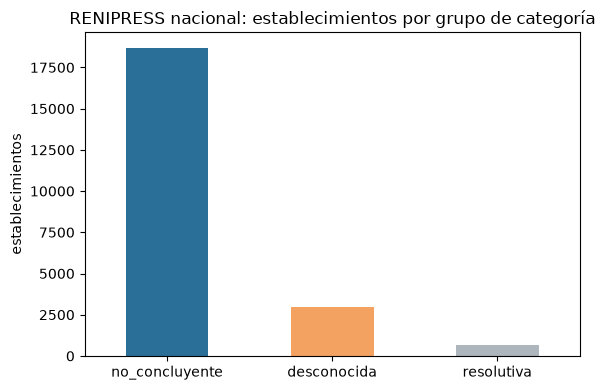

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
salud["categoria_grupo"].value_counts().plot(kind="bar", ax=ax, color=["#2a6f97", "#f4a261", "#adb5bd"])
ax.set_title("RENIPRESS nacional: establecimientos por grupo de categoría")
ax.set_xlabel("")
ax.set_ylabel("establecimientos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

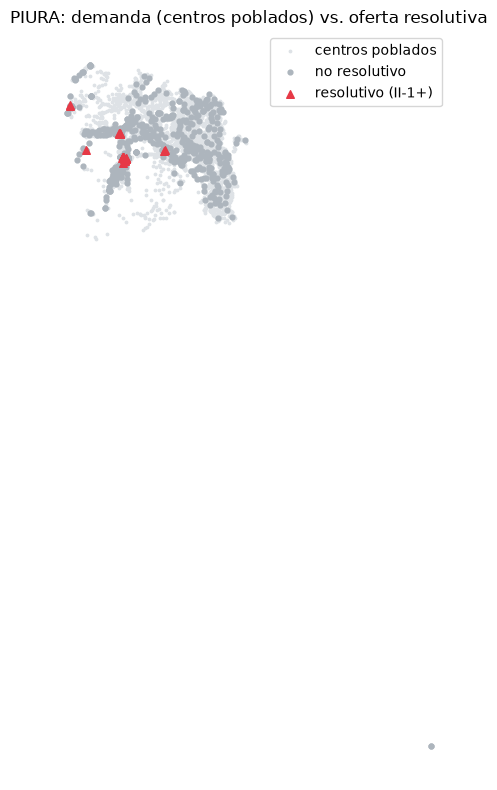

In [15]:
depto_ejemplo = departamentos_seleccionados()["costero"]
codigo_ejemplo = codigos_inei_seleccionados()[depto_ejemplo]

salud_depto = salud[salud[RENIPRESS_COLUMNAS["departamento"]].str.upper() == depto_ejemplo]
centros_depto = centros[centros[ubigeo_col_centros].astype(str).str.startswith(codigo_ejemplo)] \
    if centros is not None and ubigeo_col_centros else None

fig, ax = plt.subplots(figsize=(8, 8))
if centros_depto is not None:
    centros_depto.plot(ax=ax, color="#dee2e6", markersize=3, label="centros poblados")
salud_depto[~salud_depto["resolutiva"]].plot(ax=ax, color="#adb5bd", markersize=12, label="no resolutivo")
salud_depto[salud_depto["resolutiva"]].plot(ax=ax, color="#e63946", markersize=30, marker="^",
                                             label="resolutivo (II-1+)")
ax.set_title(f"{depto_ejemplo}: demanda (centros poblados) vs. oferta resolutiva")
ax.legend()
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Próximo paso

Con `data/processed/renipress_<depto>.gpkg` y
`data/processed/centros_poblados_<depto>.gpkg` para los 3 departamentos de
`config.md`, la Fase 2 puede construir el grafo vial a partir de
`data/raw/peru-latest.osm.pbf` y calcular el tiempo real por carretera desde
cada centro poblado hasta el establecimiento resolutivo más cercano.